In [2]:
import pandas as pd
import random

# Engine IDs from your existing project
engine_ids = [f"ENG{str(i).zfill(3)}" for i in range(1, 45)]

# Statements per category
normal_statements = [
    "everything looks fine today",
    "all systems normal",
    "no issues detected",
    "engine running smoothly",
    "oil level is good",
    "coolant level is normal",
    "battery is fully charged",
    "belt condition is good",
    "no unusual noise detected",
    "air filter is clean",
    "engine temperature is normal",
    "no vibration detected",
    "all checks passed successfully",
    "engine started without issues",
    "fluid levels are all good",
    "no leaks detected anywhere",
    "brakes and belts in good condition",
    "engine is running at normal temperature",
    "no smoke or unusual smell",
    "daily check completed no anomalies found"
]

intervention_later_statements = [
    "oil level is slightly low",
    "coolant level is below normal",
    "belt shows signs of wear",
    "air filter is slightly dirty",
    "battery voltage is a bit low",
    "minor vibration detected",
    "engine takes longer than usual to start",
    "slight oil residue near engine",
    "coolant slightly below minimum level",
    "belt tension seems slightly loose",
    "unusual smell detected but engine running",
    "oil color looks darker than usual",
    "minor noise detected during idle",
    "engine temperature slightly higher than normal",
    "small coolant stain under engine",
    "battery terminals show minor corrosion",
    "air filter needs cleaning soon",
    "oil level approaching minimum mark",
    "slight smoke detected at startup",
    "belt showing minor cracks on surface"
]

urgent_statements = [
    "oil leak detected under the engine",
    "coolant level critically low possible leak",
    "belt is broken needs immediate replacement",
    "battery completely dead engine will not start",
    "strong smoke coming from engine",
    "engine overheating immediately",
    "loud knocking noise from engine",
    "severe vibration detected in engine",
    "oil pressure warning light is on",
    "coolant leaking visibly from hose",
    "engine making grinding noise",
    "strong smell of burning oil",
    "engine stopped suddenly during check",
    "major oil leak pooling under engine",
    "belt snapped during morning check",
    "engine temperature critically high",
    "visible crack in coolant reservoir",
    "sparks detected near battery terminals",
    "engine producing black smoke continuously",
    "hydraulic fluid leaking rapidly"
]

# Generate dataset
records = []
random.seed(42)

for _ in range(70):
    records.append({
        "engine_id": random.choice(engine_ids),
        "statement": random.choice(normal_statements),
        "label": "Normal"
    })

for _ in range(70):
    records.append({
        "engine_id": random.choice(engine_ids),
        "statement": random.choice(intervention_later_statements),
        "label": "Intervention Later"
    })

for _ in range(70):
    records.append({
        "engine_id": random.choice(engine_ids),
        "statement": random.choice(urgent_statements),
        "label": "Urgent Intervention"
    })

# Create DataFrame
df = pd.DataFrame(records)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nSample records:")
print(df.head(10))

# Save to CSV
df.to_csv('daily_checks.csv', index=False)
print("\n✅ Dataset saved as daily_checks.csv")

Dataset shape: (210, 3)

Label distribution:
label
Normal                 70
Urgent Intervention    70
Intervention Later     70
Name: count, dtype: int64

Sample records:
  engine_id                                      statement  \
0    ENG019                             no issues detected   
1    ENG014             visible crack in coolant reservoir   
2    ENG008              oil color looks darker than usual   
3    ENG010         sparks detected near battery terminals   
4    ENG008                              oil level is good   
5    ENG026  battery completely dead engine will not start   
6    ENG003                   engine temperature is normal   
7    ENG009               oil pressure warning light is on   
8    ENG033       daily check completed no anomalies found   
9    ENG036            major oil leak pooling under engine   

                 label  
0               Normal  
1  Urgent Intervention  
2   Intervention Later  
3  Urgent Intervention  
4               Norm

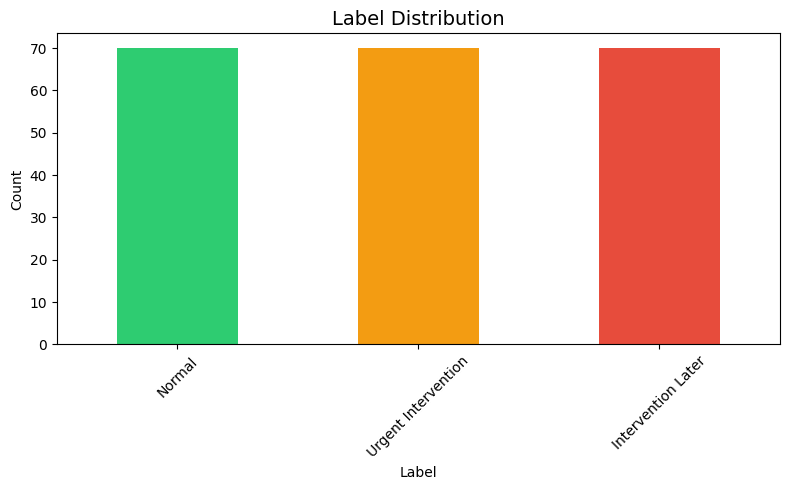

✅ Label distribution chart saved


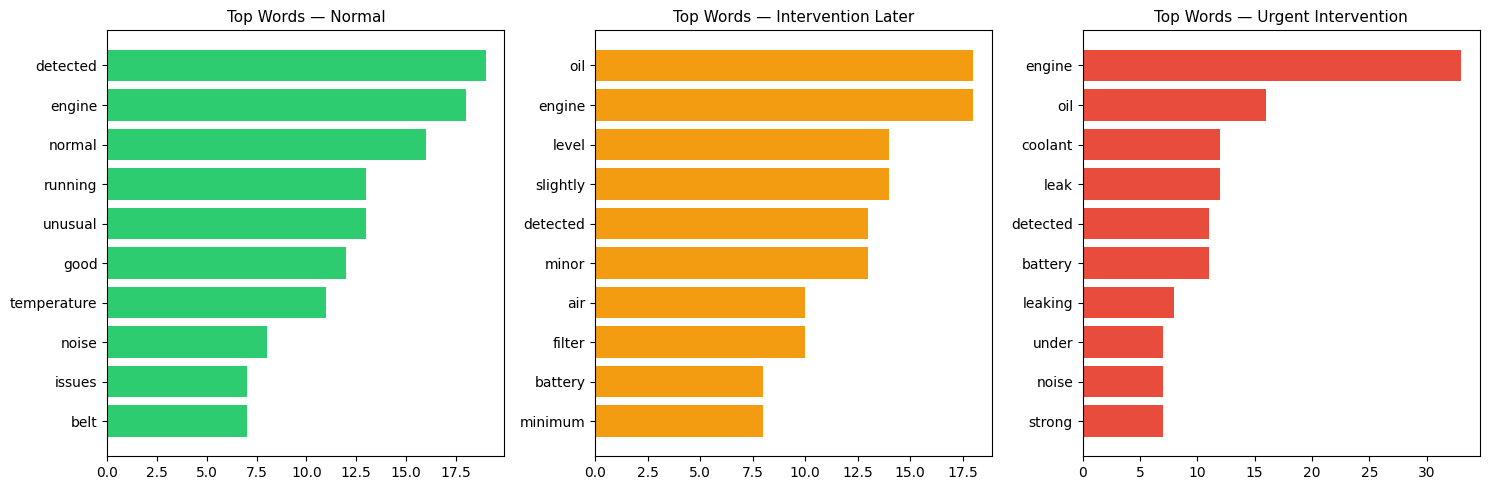

✅ Top words chart saved


In [3]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from collections import Counter
import re

# 1. Label distribution chart
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['label'].value_counts().plot(kind='bar', color=colors)
plt.title('Label Distribution', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('label_distribution.png')
plt.show()
print("✅ Label distribution chart saved")

# 2. Most frequent words per category
def get_top_words(df, label, n=10):
    text = ' '.join(df[df['label'] == label]['statement'])
    words = re.findall(r'\b\w+\b', text.lower())
    stop_words = {'is', 'the', 'a', 'an', 'at', 'in',
                  'of', 'to', 'and', 'or', 'no', 'not',
                  'from', 'during', 'than', 'all', 'looks'}
    words = [w for w in words if w not in stop_words]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
categories = ['Normal', 'Intervention Later', 'Urgent Intervention']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for ax, cat, color in zip(axes, categories, colors):
    top_words = get_top_words(df, cat)
    words, counts = zip(*top_words)
    ax.barh(words, counts, color=color)
    ax.set_title(f'Top Words — {cat}', fontsize=11)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('top_words_per_category.png')
plt.show()
print("✅ Top words chart saved")

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re

# 1. Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

# 2. Apply cleaning
df['clean_statement'] = df['statement'].apply(clean_text)

print("✅ Text cleaning done!")
print("\nOriginal vs Cleaned:")
for i in range(3):
    print(f"\nOriginal : {df['statement'][i]}")
    print(f"Cleaned  : {df['clean_statement'][i]}")

# 3. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df['clean_statement'])
y = df['label']

print(f"\n✅ TF-IDF Matrix shape: {X.shape}")
print(f"✅ Number of features: {len(tfidf.get_feature_names_out())}")

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Training set size: {X_train.shape[0]}")
print(f"✅ Test set size: {X_test.shape[0]}")


✅ Text cleaning done!

Original vs Cleaned:

Original : no issues detected
Cleaned  : no issues detected

Original : visible crack in coolant reservoir
Cleaned  : visible crack in coolant reservoir

Original : oil color looks darker than usual
Cleaned  : oil color looks darker than usual

✅ TF-IDF Matrix shape: (210, 134)
✅ Number of features: 134

✅ Training set size: 168
✅ Test set size: 42


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, lr_predictions))

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_predictions))

LOGISTIC REGRESSION RESULTS
                     precision    recall  f1-score   support

 Intervention Later       0.87      0.93      0.90        14
             Normal       1.00      1.00      1.00        14
Urgent Intervention       0.92      0.86      0.89        14

           accuracy                           0.93        42
          macro avg       0.93      0.93      0.93        42
       weighted avg       0.93      0.93      0.93        42

RANDOM FOREST RESULTS
                     precision    recall  f1-score   support

 Intervention Later       0.88      1.00      0.93        14
             Normal       1.00      1.00      1.00        14
Urgent Intervention       1.00      0.86      0.92        14

           accuracy                           0.95        42
          macro avg       0.96      0.95      0.95        42
       weighted avg       0.96      0.95      0.95        42



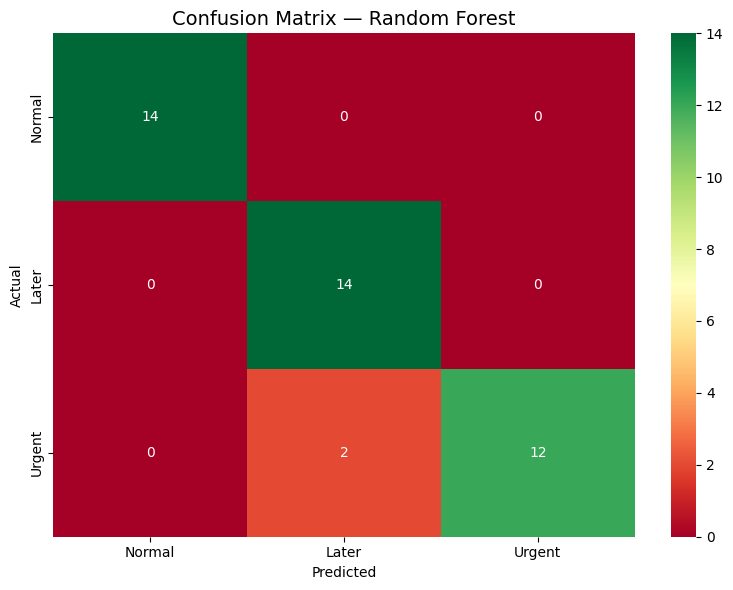

✅ Confusion matrix saved

🧠 TESTING WITH NEW SENTENCES
🟢 'engine running perfectly fine today'
   → Normal

🔴 'noticed small oil stain under engine'
   → Urgent Intervention

🔴 'massive oil leak engine cannot start'
   → Urgent Intervention

🟡 'belt looks slightly worn'
   → Intervention Later

🔴 'engine making loud grinding noise'
   → Urgent Intervention

🟢 'all fluid levels are normal'
   → Normal



In [6]:
# 1. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_predictions,
     labels=['Normal', 'Intervention Later', 'Urgent Intervention'])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Normal', 'Later', 'Urgent'],
            yticklabels=['Normal', 'Later', 'Urgent'])
plt.title('Confusion Matrix — Random Forest', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_cbms.png')
plt.show()
print("✅ Confusion matrix saved")

# 2. Test with new sentences
print("\n" + "="*50)
print("🧠 TESTING WITH NEW SENTENCES")
print("="*50)

new_statements = [
    "engine running perfectly fine today",
    "noticed small oil stain under engine",
    "massive oil leak engine cannot start",
    "belt looks slightly worn",
    "engine making loud grinding noise",
    "all fluid levels are normal"
]

new_cleaned = [clean_text(s) for s in new_statements]
new_vectorized = tfidf.transform(new_cleaned)
predictions = rf_model.predict(new_vectorized)

for statement, prediction in zip(new_statements, predictions):
    if prediction == 'Normal':
        emoji = '🟢'
    elif prediction == 'Intervention Later':
        emoji = '🟡'
    else:
        emoji = '🔴'
    print(f"{emoji} '{statement}'")
    print(f"   → {prediction}\n")

In [7]:
# Recommendation Engine
def recommend_action(statement):

    # Clean and vectorize
    cleaned = clean_text(statement)
    vectorized = tfidf.transform([cleaned])
    prediction = rf_model.predict(vectorized)[0]

    # Keyword-based recommendation
    statement_lower = statement.lower()

    if prediction == 'Normal':
        action = "✅ No action required. Log daily check as completed."
        priority = "🟢 NORMAL"

    elif prediction == 'Intervention Later':
        if 'oil' in statement_lower:
            action = "🔧 Schedule oil filter check and top up within 48 hours."
        elif 'coolant' in statement_lower or 'water' in statement_lower:
            action = "🔧 Schedule coolant level check and refill within 48 hours."
        elif 'belt' in statement_lower:
            action = "🔧 Schedule belt inspection and tension adjustment soon."
        elif 'battery' in statement_lower:
            action = "🔧 Schedule battery test and terminal cleaning soon."
        elif 'filter' in statement_lower:
            action = "🔧 Schedule air filter cleaning or replacement soon."
        else:
            action = "🔧 Schedule general inspection within 48 hours."
        priority = "🟡 INTERVENTION LATER"

    else:  # Urgent Intervention
        if 'oil' in statement_lower:
            action = "🚨 STOP ENGINE! Urgent oil system inspection required."
        elif 'coolant' in statement_lower or 'water' in statement_lower:
            action = "🚨 STOP ENGINE! Urgent cooling system inspection required."
        elif 'belt' in statement_lower:
            action = "🚨 STOP ENGINE! Belt replacement required immediately."
        elif 'battery' in statement_lower:
            action = "🚨 DO NOT START! Urgent battery replacement required."
        elif 'smoke' in statement_lower:
            action = "🚨 STOP ENGINE! Urgent inspection for fire risk."
        elif 'noise' in statement_lower or 'grinding' in statement_lower:
            action = "🚨 STOP ENGINE! Internal engine damage suspected."
        else:
            action = "🚨 STOP ENGINE! Urgent full inspection required."
        priority = "🔴 URGENT INTERVENTION"

    return prediction, priority, action

# Test the recommendation engine
print("="*60)
print("🔧 SMART MAINTENANCE RECOMMENDATION ENGINE")
print("="*60)

test_statements = [
    ("ENG001", "engine running perfectly fine today"),
    ("ENG007", "noticed small oil stain under engine"),
    ("ENG012", "massive oil leak engine cannot start"),
    ("ENG023", "belt looks slightly worn"),
    ("ENG031", "engine making loud grinding noise"),
    ("ENG044", "coolant level critically low possible leak")
]

for engine_id, statement in test_statements:
    prediction, priority, action = recommend_action(statement)
    print(f"\n🔩 Engine: {engine_id}")
    print(f"📝 Statement: '{statement}'")
    print(f"⚡ Priority: {priority}")
    print(f"🛠️  Action: {action}")
    print("-"*60)

🔧 SMART MAINTENANCE RECOMMENDATION ENGINE

🔩 Engine: ENG001
📝 Statement: 'engine running perfectly fine today'
⚡ Priority: 🟢 NORMAL
🛠️  Action: ✅ No action required. Log daily check as completed.
------------------------------------------------------------

🔩 Engine: ENG007
📝 Statement: 'noticed small oil stain under engine'
⚡ Priority: 🔴 URGENT INTERVENTION
🛠️  Action: 🚨 STOP ENGINE! Urgent oil system inspection required.
------------------------------------------------------------

🔩 Engine: ENG012
📝 Statement: 'massive oil leak engine cannot start'
⚡ Priority: 🔴 URGENT INTERVENTION
🛠️  Action: 🚨 STOP ENGINE! Urgent oil system inspection required.
------------------------------------------------------------

🔩 Engine: ENG023
📝 Statement: 'belt looks slightly worn'
⚡ Priority: 🟡 INTERVENTION LATER
🛠️  Action: 🔧 Schedule belt inspection and tension adjustment soon.
------------------------------------------------------------

🔩 Engine: ENG031
📝 Statement: 'engine making loud grinding n

In [8]:
import datetime

# Archive storage
archive = []

def log_intervention(engine_id, statement, date=None):

    # Get prediction and recommendation
    prediction, priority, action = recommend_action(statement)

    # Use today's date if not provided
    if date is None:
        date = datetime.date.today().strftime("%Y-%m-%d")

    # Create record
    record = {
        "date": date,
        "engine_id": engine_id,
        "statement": statement,
        "classification": prediction,
        "priority": priority,
        "action": action,
        "status": "Logged"
    }

    # Add to archive
    archive.append(record)

    return record

# Simulate a week of technician reports
print("="*60)
print("📋 SIMULATING ONE WEEK OF TECHNICIAN REPORTS")
print("="*60)

weekly_reports = [
    ("2026-05-12", "ENG001", "engine running perfectly fine today"),
    ("2026-05-12", "ENG007", "noticed small oil stain under engine"),
    ("2026-05-12", "ENG012", "massive oil leak engine cannot start"),
    ("2026-05-13", "ENG001", "all systems normal"),
    ("2026-05-13", "ENG007", "oil level still low needs attention"),
    ("2026-05-13", "ENG023", "belt looks slightly worn"),
    ("2026-05-14", "ENG001", "engine running smoothly"),
    ("2026-05-14", "ENG012", "engine making loud grinding noise"),
    ("2026-05-14", "ENG031", "coolant level critically low"),
    ("2026-05-15", "ENG007", "oil filter replaced running fine now"),
    ("2026-05-15", "ENG023", "belt tension adjusted no more noise"),
    ("2026-05-15", "ENG031", "coolant refilled level back to normal"),
]

for date, engine_id, statement in weekly_reports:
    record = log_intervention(engine_id, statement, date)
    print(f"\n📅 {record['date']} | 🔩 {record['engine_id']}")
    print(f"📝 '{record['statement']}'")
    print(f"⚡ {record['priority']}")
    print(f"🛠️  {record['action']}")

# Save archive to CSV
archive_df = pd.DataFrame(archive)
archive_df.to_csv('interventions_archive.csv', index=False)

print("\n" + "="*60)
print(f"✅ Archive saved! Total records: {len(archive)}")
print("="*60)
print(archive_df[['date', 'engine_id', 'classification', 'status']].to_string())

📋 SIMULATING ONE WEEK OF TECHNICIAN REPORTS

📅 2026-05-12 | 🔩 ENG001
📝 'engine running perfectly fine today'
⚡ 🟢 NORMAL
🛠️  ✅ No action required. Log daily check as completed.

📅 2026-05-12 | 🔩 ENG007
📝 'noticed small oil stain under engine'
⚡ 🔴 URGENT INTERVENTION
🛠️  🚨 STOP ENGINE! Urgent oil system inspection required.

📅 2026-05-12 | 🔩 ENG012
📝 'massive oil leak engine cannot start'
⚡ 🔴 URGENT INTERVENTION
🛠️  🚨 STOP ENGINE! Urgent oil system inspection required.

📅 2026-05-13 | 🔩 ENG001
📝 'all systems normal'
⚡ 🟢 NORMAL
🛠️  ✅ No action required. Log daily check as completed.

📅 2026-05-13 | 🔩 ENG007
📝 'oil level still low needs attention'
⚡ 🟡 INTERVENTION LATER
🛠️  🔧 Schedule oil filter check and top up within 48 hours.

📅 2026-05-13 | 🔩 ENG023
📝 'belt looks slightly worn'
⚡ 🟡 INTERVENTION LATER
🛠️  🔧 Schedule belt inspection and tension adjustment soon.

📅 2026-05-14 | 🔩 ENG001
📝 'engine running smoothly'
⚡ 🟢 NORMAL
🛠️  ✅ No action required. Log daily check as completed.

📅 2026-

In [9]:
# Archive Intelligence
print("="*60)
print("📊 ARCHIVE INTELLIGENCE REPORT")
print("="*60)

# 1. Summary by engine
print("\n🔩 INTERVENTIONS PER ENGINE:")
print(archive_df.groupby(['engine_id', 'classification'])
      .size().reset_index(name='count').to_string())

# 2. Most problematic engines
print("\n⚠️ MOST PROBLEMATIC ENGINES:")
problematic = archive_df[
    archive_df['classification'] != 'Normal'
].groupby('engine_id').size().sort_values(ascending=False)
print(problematic.head(5).to_string())

# 3. Urgent interventions history
print("\n🚨 URGENT INTERVENTIONS HISTORY:")
urgent = archive_df[
    archive_df['classification'] == 'Urgent Intervention'
][['date', 'engine_id', 'statement', 'action']]
print(urgent.to_string())

# 4. Next maintenance recommendation
print("\n📅 NEXT MAINTENANCE RECOMMENDATION:")
for engine_id in archive_df['engine_id'].unique():
    engine_records = archive_df[
        archive_df['engine_id'] == engine_id
    ]
    urgent_count = len(engine_records[
        engine_records['classification'] == 'Urgent Intervention'
    ])
    later_count = len(engine_records[
        engine_records['classification'] == 'Intervention Later'
    ])

    if urgent_count > 0:
        print(f"🔴 {engine_id} — Full inspection required")
    elif later_count > 0:
        print(f"🟡 {engine_id} — Schedule maintenance soon")
    else:
        print(f"🟢 {engine_id} — Continue normal schedule")

📊 ARCHIVE INTELLIGENCE REPORT

🔩 INTERVENTIONS PER ENGINE:
  engine_id       classification  count
0    ENG001               Normal      3
1    ENG007   Intervention Later      2
2    ENG007  Urgent Intervention      1
3    ENG012  Urgent Intervention      2
4    ENG023   Intervention Later      1
5    ENG023               Normal      1
6    ENG031   Intervention Later      2

⚠️ MOST PROBLEMATIC ENGINES:
engine_id
ENG007    3
ENG012    2
ENG031    2
ENG023    1

🚨 URGENT INTERVENTIONS HISTORY:
         date engine_id                             statement                                                 action
1  2026-05-12    ENG007  noticed small oil stain under engine  🚨 STOP ENGINE! Urgent oil system inspection required.
2  2026-05-12    ENG012  massive oil leak engine cannot start  🚨 STOP ENGINE! Urgent oil system inspection required.
7  2026-05-14    ENG012     engine making loud grinding noise       🚨 STOP ENGINE! Internal engine damage suspected.

📅 NEXT MAINTENANCE RECOMMENDATI

In [10]:
print("✅ Files saved in this project:")
print("1. daily_checks.csv")
print("2. interventions_archive.csv")
print("3. label_distribution.png")
print("4. top_words_per_category.png")
print("5. confusion_matrix_cbms.png")

✅ Files saved in this project:
1. daily_checks.csv
2. interventions_archive.csv
3. label_distribution.png
4. top_words_per_category.png
5. confusion_matrix_cbms.png


In [11]:
import os

files = [
    'daily_checks.csv',
    'interventions_archive.csv',
    'label_distribution.png',
    'top_words_per_category.png',
    'confusion_matrix_cbms.png'
]

print("📁 Checking files in Colab:")
for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✅ {file} — {size} bytes")
    else:
        print(f"❌ {file} — NOT FOUND")

📁 Checking files in Colab:
✅ daily_checks.csv — 11436 bytes
✅ interventions_archive.csv — 1860 bytes
✅ label_distribution.png — 23029 bytes
✅ top_words_per_category.png — 38506 bytes
✅ confusion_matrix_cbms.png — 23200 bytes


In [12]:
from google.colab import files

# Download all files
files.download('daily_checks.csv')
files.download('interventions_archive.csv')
files.download('label_distribution.png')
files.download('top_words_per_category.png')
files.download('confusion_matrix_cbms.png')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


In [13]:
# ============================================
# 🔧 INTERACTIVE MAINTENANCE ASSISTANT
# Type any technician statement and get
# an instant maintenance recommendation!
# ============================================

from IPython.display import display, HTML
import ipywidgets as widgets

# Title
display(HTML("""
<div style="background-color:#1e1e2e; padding:20px; border-radius:10px; margin-bottom:10px">
    <h2 style="color:#00d4ff; text-align:center;">🔧 Smart Maintenance Assistant</h2>
    <p style="color:#ffffff; text-align:center;">Type what the technician observed this morning</p>
</div>
"""))

# Engine ID input
engine_input = widgets.Text(
    placeholder='e.g. ENG007',
    description='Engine ID:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Statement input
statement_input = widgets.Textarea(
    placeholder='e.g. oil leak detected under the engine...',
    description='Statement:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px', height='100px')
)

# Submit button
button = widgets.Button(
    description='🔍 Analyze Statement',
    button_style='primary',
    layout=widgets.Layout(width='400px', height='40px')
)

# Output area
output = widgets.Output()

# Button click function
def on_button_click(b):
    with output:
        output.clear_output()

        engine_id = engine_input.value.strip()
        statement = statement_input.value.strip()

        if not statement:
            display(HTML("<p style='color:red'>⚠️ Please enter a statement!</p>"))
            return

        if not engine_id:
            engine_id = "UNKNOWN"

        # Get prediction and recommendation
        prediction, priority, action = recommend_action(statement)

        # Color based on priority
        if prediction == 'Normal':
            color = '#2ecc71'
            bg = '#0d2b1a'
        elif prediction == 'Intervention Later':
            color = '#f39c12'
            bg = '#2b1f0a'
        else:
            color = '#e74c3c'
            bg = '#2b0a0a'

        # Display result
        display(HTML(f"""
        <div style="background-color:{bg}; padding:20px;
                    border-radius:10px; border-left:5px solid {color};
                    margin-top:10px">
            <h3 style="color:{color};">{priority}</h3>
            <p style="color:#ffffff;"><b>🔩 Engine:</b> {engine_id}</p>
            <p style="color:#ffffff;"><b>📝 Statement:</b> {statement}</p>
            <p style="color:#ffffff;"><b>🛠️ Action:</b> {action}</p>
        </div>
        """))

button.on_click(on_button_click)

# Display everything
display(engine_input)
display(statement_input)
display(button)
display(output)

Text(value='', description='Engine ID:', layout=Layout(width='400px'), placeholder='e.g. ENG007', style=Descri…

Textarea(value='', description='Statement:', layout=Layout(height='100px', width='400px'), placeholder='e.g. o…

Button(button_style='primary', description='🔍 Analyze Statement', layout=Layout(height='40px', width='400px'),…

Output()